In [1]:
import numpy as np
import pandas as pd

from numba import jit, prange, njit
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from pyscarcopula.src.Frank.FrankCopula  import ArchimedianCopula
from pyscarcopula.src.Gumbel.GumbelCopula  import GumbelCopula
from pyscarcopula.src.Joe.JoeCopula  import JoeCopula

from pyscarcopula.auxiliary.funcs import jit_pobs, pobs
import math
from scipy.optimize import minimize, Bounds

from typing import Literal


In [2]:
moex_data = pd.read_csv("data/moex_top.csv", index_col=0)
#tickers = ['AFLT', 'LSRG', 'GAZP', 'NLMK']
tickers = ['AFLT', 'LSRG', 'GAZP', 'NLMK', 'ROSN', 'KMAZ', 'AFKS', 'BSPB', 'MGNT']

moex_returns_pd = np.log(moex_data[tickers] / moex_data[tickers].shift(1))[1:601]
moex_returns = moex_returns_pd.values
pobs_data = pobs(moex_returns)


count_instruments = len(tickers)
copula = JoeCopula(count_instruments)

In [94]:
@jit(nopython=True, parallel = True, cache = True)
def p_sampler_ou(alpha, dwt, init_state = None):
    #alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    theta, mu, nu = alpha[0], alpha[1], alpha[2]

    T = len(dwt)
    latent_process_tr = len(dwt[0])
    dt = 1 / T
    xt = np.zeros((T + 1, latent_process_tr))
    #mu = -alpha1 / alpha2
    if init_state is None:
        xt[0] = mu
    else:
        xt[0] = init_state
    for k in range(1, T + 1):
        A = -theta * (xt[k - 1] - mu)
        B = nu
        xt[k] = xt[k - 1] + A * dt + B * dwt[k - 1]
    return xt[1:]

@jit(nopython = True, cache = True, parallel = True)
def get_avg_p_log_likelihood_ou(data, lambda_data, latent_process_tr, pdf, transform):
    avg_likelihood = 0
    copula_log_data = np.zeros(latent_process_tr)

    for k in prange(0, latent_process_tr):
        copula_log_data[k] = np.sum(np.log(np.maximum(pdf(data, transform(lambda_data[:,k])), 1e-100)))

    '''trick for calculation large values. calculate e^(sum(log_cop) - corr) instead of e^(sum(log_cop)).
    Do inverse correction at the end of calculations'''
    corr = max(copula_log_data)
    avg_likelihood = np.sum(np.exp(copula_log_data - corr)) / latent_process_tr
    return math.log(avg_likelihood) + corr


@jit(nopython = True, cache = True)
def p_jit_mlog_likelihood_ou(alpha: np.array, data: np.array, dwt: np.array, latent_process_tr: int,
                      print_path: bool, pdf: callable, transform: callable, init_state: np.array = None) -> float:
    
    '''initial data check'''
    if np.isnan(np.sum(alpha)) == True:
        res = 10000
        if print_path == True:
            print(alpha, 'incorrect params', res)
        return res
    
    lambda_data = p_sampler_ou(alpha, dwt, init_state)
    avg_log_likelihood = get_avg_p_log_likelihood_ou(data.T, lambda_data, latent_process_tr, pdf, transform)
    res = - avg_log_likelihood
    if np.isnan(res) == True:
        if print_path == True:
            print(alpha, 'unknown error', res)
    else:
        if print_path == True:
            print(alpha, res)
    return res


In [4]:
@jit(nopython=True, cache = True)
def moving_average(a, n = 3):
    ret = np.cumsum(a)
    ret[n:] = ret[n:] - ret[:-n]
    ret = ret[n - 1:] / n
    lin_arr1 = np.linspace(a[0], ret[0], n//2)
    index = len(a) - (len(lin_arr1) + len(ret))
    lin_arr2 = np.linspace(ret[-1], a[-1], index)
    ret = np.concatenate((lin_arr1, ret, lin_arr2 ))
    return ret

@jit(nopython=True, cache = True)
def poly_fit(x, y, dim, fit_intercept = True, ridge_alpha = 0.0):
    '''least squares fit y = f(x), where f(x) - polynom with dimension = dim'''
    fi = int(fit_intercept)
    A = np.zeros((len(x), dim + fi))
    x_i = x
    for i in range(0, dim):
        #A[:,i + fi] = x**(i + 1)
        A[:,i + fi] = x_i
        x_i = x_i  * x
    if fit_intercept == True:
        A[:,0] = np.ones(len(x))
    res = linear_least_squares(A, y, ridge_alpha)
    return res

@jit(nopython=True, cache = True)
def poly(data, coef, intercept = True):
    '''returns polynom of data (c0 + c1 t + c2 t^2 + ...) with coeficients = coef. 
    If intercept == True: first coef considered as free parameter c0; Otherwise - as c1.'''
    dim = len(coef)
    res = np.zeros(len(data))
    fi = int(intercept)
    for i in range(0, dim):
        res += coef[i] * data**(1 - fi + i)
    return res



@jit(nopython=True, cache = True)
def bounded_polynom_fit(x, y, dim, type: Literal['two-sided', 'left-sided', 'right-sided', 'no bounds'], ridge_alpha = 0.0):
    if type == 'two-sided':
        x0 = x[0]
        x1 = x[-1]
        y0 = y[0]
        y1 = y[-1]
        c0 = (y0 * x1 - y1 * x0) / (x1 - x0)
        c1 = (y1 - y0) / (x1 - x0)
        d1 = -x0 - x1
        d2 = x0 * x1
        A = np.zeros((len(x), dim))
        x_i = np.ones(len(x))
        for i in range(0, dim):
            A[:,i] = x_i * x * x + d1 * x_i * x + d2 * x
            x_i = x_i  * x
        A[:,0] += np.ones(len(x)) * c0
        A[:,1] += x * c1
        res = linear_least_squares(A, y, ridge_alpha)
        return res
    elif type == 'no bounds':
        fi = 1
        A = np.zeros((len(x), dim + fi))
        x_i = x
        for i in range(0, dim):
            A[:,i + fi] = x_i
            x_i = x_i  * x
        A[:,0] = np.ones(len(x))
        res = linear_least_squares(A, y, ridge_alpha)
        return res
    elif type == 'left-sided':
        x0 = x[0]
        y0 = y[0]
        A = np.zeros((len(x), dim))
        x_i = np.ones(len(x))
        for i in range(0, dim):
            A[:,i] = x_i * (x - x0)
            x_i = x_i  * x
        res = linear_least_squares(A, y - y0, ridge_alpha)
        return res
    elif type == 'right-sided':
        x0 = x[-1]
        y0 = y[-1]
        A = np.zeros((len(x), dim))
        x_i = np.ones(len(x))
        for i in range(0, dim):
            A[:,i] = x_i * (x - x0)
            x_i = x_i  * x
        res = linear_least_squares(A, y - y0, ridge_alpha)
        return res
    else:
        raise ValueError(f"type = {type} not implemented")


@jit(nopython=True, cache = True)
def bounded_polynom(x, y, coef, type: Literal['two-sided', 'left-sided', 'right-sided', 'no bounds']):
    if type == 'two-sided':
        dim = len(coef)
        x0 = x[0]
        x1 = x[-1]
        y0 = y[0]
        y1 = y[-1]
        c0 = (y0 * x1 - y1 * x0) / (x1 - x0)
        c1 = (y1 - y0) / (x1 - x0)
        d1 = -x0 - x1
        d2 = x0 * x1
        res = np.zeros(len(x))
        x_i = np.ones(len(x))
        for i in range(0, dim):
            res += coef[i] * x_i
            x_i = x_i * x
        return (x * x + d1 * x + d2) * res + c1 * x + c0
    elif type == 'no bounds':
        dim = len(coef)
        res = np.zeros(len(x))
        fi = 1
        for i in range(0, dim):
            res += coef[i] * x**(1 - fi + i)
        return res
    elif type == 'left-sided':
        dim = len(coef)
        x0 = x[0]
        y0 = y[0]
        res = np.zeros(len(x))
        x_i = np.ones(len(x))
        for i in range(0, dim):
            res += coef[i] * (x - x0) * x_i
            x_i = x_i * x
        return res + y0
    elif type == 'right-sided':
        dim = len(coef)
        x0 = x[-1]
        y0 = y[-1]
        res = np.zeros(len(x))
        x_i = np.ones(len(x))
        for i in range(0, dim):
            res += coef[i] * x_i
            x_i = x_i * x
        return y0 + (x - x0) * res
    else:
        raise ValueError(f"type = {type} not implemented")


@jit(nopython=True, cache = True)
def mod_abs(x):
    b = 1
    #res = x * (2 / (1 + np.exp(-b * x)) - 1)
    res = x * np.tanh(b * x)
    return res

@jit(nopython=True, cache = True)
def poly_corr(t_data, coef, alpha, intercept):
    '''correct polynom fit result to be below a threshold that raises from norm constant'''
    res = poly(t_data, coef, intercept)
    alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    sigma2 = alpha3**2 / (- 2 * alpha2) * (1 - np.exp(2 * alpha2 * t_data)) + 0.0001
    #max_res = 1 / (2 * sigma2[-1]) - 0.5
    max_res = 1 / (2 * sigma2) - 0.0
    #max_res = 0.0
    exp_res = np.exp(-0.5*(max_res - res))
    return 1 / (1 + exp_res) * res
    #return -(mod_abs(max_res - res) - max_res - res) / 2


@jit(nopython=True, cache = True)
def correction(t_data, x_data, alpha):
    #alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    theta, mu, nu = alpha[0], alpha[1], alpha[2]
    sigma2 = nu**2 / (2 * theta) * (1 - np.exp(-2 * theta * t_data)) + 0.0001
    max_res = 1 / (2 * sigma2) - 0.1
    exp_res = np.exp(-0.5*(max_res - x_data))
    return 1 / (1 + exp_res) * x_data
    #max_res = 0.0
    #return -(mod_abs(max_res - x_data) - max_res - x_data) / 2


def alpha_params(alpha):
    alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    mu = -alpha1 / alpha2
    theta = -alpha2
    nu = alpha3  
    D = nu**2/2
    print(f'alpha1 = {alpha1}, alpha2 = {alpha2}, alpha3 = {alpha3}')
    print(f'theta = {theta}, mu = {mu}, nu = {nu}, D = {D}')


In [886]:
@jit(nopython=True, cache = True)
def log_norm_ou(alpha: np.array, a1: np.array, a2: np.array, t: np.array, x0: np.array):
    #alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    theta, mu, nu = alpha[0], alpha[1], alpha[2]
    # mu = -alpha1 / alpha2
    # theta = -alpha2
    # nu = alpha3
    D = nu**2/2
    sigma2 = D/theta * (1 - np.exp(-2 * theta * t))
    #xs = mu + x0 * np.exp(alpha2 * t)
    xs = (x0 - mu) * np.exp(-theta * t) + mu
    res = (a1**2 * sigma2 + 2 * a1 * xs + 2 * a2 * xs**2) / (2 - 4 * a2 * sigma2) - 0.5 * np.log(1 - 2*a2*sigma2) #np.log1p(-2 * a2 * sigma2)
    return res

@jit(nopython=True, cache = True)
def m_sampler_ou(alpha, a1t, a2t, dwt, init_state = None):
    theta, mu, nu = alpha[0], alpha[1], alpha[2]

    T = len(dwt)
    latent_process_tr = len(dwt[0])
    dt = 1 / T
    xt = np.zeros((T + 1, latent_process_tr))
    D = nu**2 / 2
    if init_state is None:
        xt[0] = mu
    else:
        xt[0] = init_state
    for i in range(1, T + 1):
        a1, a2 = a1t[i - 1], a2t[i - 1]
        if i == 1:
            a1dt, a2dt =  (a1t[i] - a1t[i - 1]) / dt, (a2t[i] - a2t[i - 1]) / dt
        else:
            a1dt, a2dt =  (a1t[i - 1] - a1t[i - 2]) / dt, (a2t[i - 1] - a2t[i - 2]) / dt
        #a1dt, a2dt = 0, 0
        t = i/T
        sigma2 = D / theta * (1 - np.exp(- 2 * theta * t))
        p = (1 - 2 * a2 * sigma2)
        sigma2w = sigma2 / p
        xs = (xt[0] - mu) * np.exp(-theta * t) + mu
        xsw = (xs + a1 * sigma2) / p
        sigma2dt = nu**2 - 2 * theta * sigma2
        sigma2wdt = (sigma2dt + 2 * sigma2**2 * a2dt) / p**2
        xsdt = -theta * (xs - mu)
        xswdt = (xsdt + a1 * sigma2dt + a1dt * sigma2) / p + 2 * xsw * (a2dt * sigma2 + a2 * sigma2dt) / p
        B = nu
        #B = nu * (1 + a2 * sigma2w)
        A = xswdt - (xt[i - 1] - xsw) * (B**2 - sigma2wdt) / (2 * sigma2w)
        xt[i] = xt[i - 1] + A * dt + B * dwt[i - 1]
    return xt[1:]

In [7]:
@jit(nopython=True, cache = True)
def check_a2_bounds(alpha, x, t):
    theta, mu, nu = alpha[0], alpha[1], alpha[2]
    sigma2 = nu**2 / (2 * theta) * (1 - np.exp(-2 * theta * t))
    ub = 1/(2 * sigma2 + 0.001)
    bound_check = True
    for k in range(0, len(x)):
        if x[k] >= ub[k]:
            bound_check = False
            return bound_check
    return bound_check

In [220]:
@jit(nopython=True, cache = True)
def linear_least_squares(matA: np.array, matB: np.array, ridge_alpha = 0.0, pseudo_inverse = False) -> np.array:
    '''Ridge regression
       Input  Ax = b
       Output x = (A.T * A + alpha * I)^(-1) * A.T * b

       Solution with pseudoinverse matrix:
       Input Ax = b
       Output x = A^(+) * b
       where A^(+) - pseudoinverse matrix
    '''
    if pseudo_inverse == False:
        I = np.identity(len(matA[0]))
        #I[0][0] = 0
        result = np.linalg.inv(matA.T @ matA + ridge_alpha * I) @ matA.T @ matB
    else:
        result = np.linalg.pinv(matA) @ matB
    return result

In [9]:
i = 0
data = pobs(moex_returns[0 + i:250 + i])
T = len(data)
latent_process_tr = 500

In [10]:
T = len(data)
#s = np.random.randint(0, 100000)
s = 15921
rng = np.random.RandomState(seed=s)
dwt = rng.normal(0, 1, size = (len(pobs_data), latent_process_tr)) * np.sqrt(1/T)
dwt = dwt[i:len(data) + i]

In [ ]:
#bounds = Bounds([-700., -700, 0.0], [700, 700, 700])
latent_process_tr = 500
data = pobs_data[0:250]

alpha = np.array([20.40351061, 0.49428505, 0.47159938])


constr = {'type': 'ineq', 'fun': lambda x: np.abs(x[1]) - x[2]**2 - 0.001}

log_min = minimize(m_jit_mlog_likelihood_ou, alpha,
                            args=(data, dwt, latent_process_tr, 5, True, copula.np_pdf(), copula.transform, init_state),
                            method='SLSQP',
                            #bounds = bounds,
                            #constraints = constr,
                            options={'ftol': 1e-4} )
log_min

In [993]:
#@jit(nopython=True, cache = True, parallel = True)
def m_jit_mlog_likelihood_ou(alpha, data, dwt, latent_process_tr, m_iters, print_path, 
                             pdf, transform, init_state = None):
    T = len(data)
    norm_log_data = np.zeros((T, latent_process_tr))
    dt = 1/T
    t_data = np.linspace(0, 1, T)
    a_data = np.zeros((T, 3))
    theta, mu, nu = alpha[0], alpha[1], alpha[2]
    a1t = np.zeros(T)
    a2t = np.zeros(T)
    for j in range(0, m_iters):
        if j == 0:
            lambda_data = p_sampler_ou(alpha, dwt, init_state)
        else:
            lambda_data = m_sampler_ou(alpha, a1t, a2t, dwt, init_state)
            if np.isnan(np.sum(lambda_data)) == True:
                res = 10**10
                if print_path == True:
                    print(alpha, 'm sampler nan', res)
                return res
        norm_log_data = np.zeros((T, latent_process_tr))
        a_mean = np.zeros(3)

        a_mean[0] = np.mean(a_data[:,0])
        a_mean[1] = np.mean(a_data[:,1])

        sigma2 = nu**2 / (2 * theta) * (1 - np.exp(-2 * theta))
        ub = np.maximum(1/(2 * sigma2) - 0.1, 0)
        a_mean[2] = np.minimum(np.mean(a_data[:,2]), ub)

        a_data = np.zeros((T, 3))
        a_data[-1] = a_mean
        for i in range(T - 1, 0 , -1):
            copula_log_data = np.log(np.maximum(pdf(data[i], transform(lambda_data[i])), 1e-100))
            A = np.dstack( ( np.ones(latent_process_tr) , (lambda_data[i] - 0 * mu) , (lambda_data[i] - 0 * mu)**2 ) )[0]
            norm_log_data[i] = log_norm_ou(alpha, a_data[i][1], a_data[i][2], dt, lambda_data[i - 0 * 1])

            b = copula_log_data + norm_log_data[i]
            #print(norm_log_data[i])
            sigma2 = nu**2 / (2 * theta) * (1 - np.exp(-2 * theta * (t_data[i])))
            #r = sigma2
            r = 0.0
            ub = np.maximum(1/(2 * sigma2) - 0.1, 0)
            #ub = 0.0
            a_data[i - 1] = linear_least_squares(A, b, r, pseudo_inverse = True)

            # try:
            #     a_data[i - 1] = linear_least_squares(A, b, r)
            # except:
            #     try:
            #         a_data[i - 1] = linear_least_squares(A, b, r, pseudo_inverse = True)
            #     except:
            #         res = 10**10
            #         if print_path == True:
            #             print(alpha, 'ls problem fail', res, i)
            #         return res
            a_data[i - 1][2] = np.minimum(a_data[i - 1][2], ub)
            #a_data[i - 1] = np.maximum(np.minimum(a_data[i - 1], 300),-300)

        a_data_a1 = a_data[:,1].copy()
        a_data_a2 = a_data[:,2].copy()

        # val = np.minimum(np.mean(a_data_a2), 0)
        # if a_data_a2[-1] > val:
        #     a_data_a2[-1] = val

        fit_type1 = 'right-sided'#'no bounds'
        fit_type2 = 'right-sided'
        dim = j + 1
        #dim = 2

        rigde_alpha_list = np.array([0.0, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0])
        for r in rigde_alpha_list:
            a2_params = bounded_polynom_fit(t_data, a_data_a2, dim = dim, ridge_alpha = r, type = fit_type2)
            a2t = bounded_polynom(t_data, a_data_a2, a2_params, type = fit_type2)
            bound_check = check_a2_bounds(alpha, a2t, t_data)
            if bound_check == True:
                print(r)
                break
            else:
                continue
        if r == rigde_alpha_list[-1]:
            print(r)
            a2t = correction(t_data, a2t, alpha)
    
        # r = 0.0#np.log(np.abs(theta/nu**2))
        # a2_params = bounded_polynom_fit(t_data, a_data_a2, dim = dim, ridge_alpha = r, type = fit_type2)
        # a2t = bounded_polynom(t_data, a_data_a2, a2_params, type = fit_type2)
        # bound_check = check_a2_bounds(alpha, a2t, t_data)
        # if bound_check == False:
        #     a2t = correction(t_data, a2t, alpha)
        a1_params = bounded_polynom_fit(t_data, a_data_a1, dim = dim, ridge_alpha = r, type = fit_type1)
        a1t = bounded_polynom(t_data, a_data_a1, a1_params, type = fit_type1)  

    print(a2_params)
    lambda_data = m_sampler_ou(alpha, a1t, a2t, dwt, init_state)
    log_likelihood = np.zeros(latent_process_tr)
    norm_log_data = np.zeros((T, latent_process_tr))
    
    if np.isnan(np.sum(lambda_data)) == True:
        res = 10**10
        if print_path == True:
            print(alpha, 'm sampler nan', res)
            return res
        
    for i in range(T - 1, 0, -1):
        a1, a2 = a1t[i], a2t[i]
        norm_log_data[i] = log_norm_ou(alpha, a1, a2, dt, lambda_data[i - 1])
    if init_state is None:
        x0 = mu * np.ones(latent_process_tr)
    else:
        x0 = init_state
    norm_log_data[0] =  log_norm_ou(alpha, a1t[0], a2t[0], dt, x0)

    for k in range(0, latent_process_tr):
        copula_log_data = np.log(np.maximum(pdf(data.T, transform(lambda_data[:,k])), 1e-100))
        g = (a1t * (lambda_data[:,k] - 0 * mu)  + a2t * (lambda_data[:,k] - 0 * mu)**2)
        #g[0] = 0
        log_likelihood[k] = np.sum(copula_log_data + norm_log_data[:,k] - g)
        #print(norm_log_data[:,k][0:10], g[0:10])
    xc = np.max(log_likelihood)
    avg_likelihood = np.sum(np.exp(log_likelihood - xc)) / latent_process_tr
    res = np.log(avg_likelihood) + xc
    res = -res
    if print_path == True:
        print(alpha, res)
    return res#a_data


In [16]:
s = 15921
rng = np.random.RandomState(seed = s)
dt = 1.0/250
print(s)
dwt = rng.normal(0, 1, size = (T, latent_process_tr)) * np.sqrt(dt)
j = 349
data = pobs(moex_returns[0 + j:250 + j])

15921


In [56]:
alpha = np.array([-0.34741403 , 1.71949998 ,-0.14467107])
moex_returns_pd = np.log(moex_data[tickers] / moex_data[tickers].shift(1))[1:251]
moex_returns = moex_returns_pd.values
data = pobs(moex_returns)
s = 25400
rng = np.random.RandomState(seed= s)
dwt = rng.normal(0, 1, size = (len(data), 500)) * np.sqrt(1/len(data))
copula.mlog_likelihood(alpha, data, method='scar-m-ou', dwt = dwt)

14.09041213658838

In [785]:
from pyscarcopula.sampler.sampler_ou import m_jit_mlog_likelihood_ou

In [992]:
#%%timeit
s = np.random.randint(0, 1000000)
#s = 86684
#s = 25400
#s = 10
rng = np.random.RandomState(seed= s)
dwt = rng.normal(0, 1, size = (len(data), latent_process_tr)) * np.sqrt(1/len(data))
i = 0
#dwt = dwt[i:len(data) + i]

#alpha = np.array([-0.56395007,  2.59290612, -1.41567972])
#alpha = np.array([4.51551114, -0.41554241, -0.29707367])
#alpha = np.array([0.74446907,  0.69987999, -0.04472599])
#alpha = np.array([0.56390725, -0.61465765,  0.42402798])
#alpha = np.array([0.92330527,  0.22826444, -0.85666308])
#alpha = np.array([100.       ,    0.58042304 ,  1.55060208])
alpha = np.array([-3.06908433,  1.030595,   -0.111905801])
#alpha = np.array([-0.54018946,  0.85256699,  0.23002057])
#alpha = np.array([-0.47884225, 0.17273891,  0.16327304])
#alpha = np.array([4.62457538e+01, 5.53740378e-01, 5.49935376e-05])
#alpha = np.array([-0.34741403 , 1.71949998 ,-0.14467107])
#alpha = np.array([98.293350,	-0.858017,	0.011785])
#init_state = None
p_jit_mlog_likelihood_ou(alpha, data, dwt, latent_process_tr, True, copula.np_pdf(), copula.transform, init_state= None)


a_data = m_jit_mlog_likelihood_ou(alpha, data, dwt, latent_process_tr, 15, True, 
                                  copula.np_pdf(), copula.transform, init_state=None)

[-3.06908433  1.030595   -0.1119058 ] -119.93079025222342
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
[ 1.42443401e+01  1.04847201e+03 -2.85694247e+04  2.30645162e+05
  4.68612409e+05 -2.11761585e+07  1.60671816e+08 -6.21728084e+08
  1.39177067e+09 -1.76703602e+09  9.52219261e+08  4.85214680e+08
 -1.08791471e+09  6.46306360e+08 -1.39000721e+08]
[-3.06908433  1.030595   -0.1119058 ] -116.6529734798614


In [25]:
from pyscarcopula.metrics.latent_process import latent_process_sampler_one_step

In [18]:
latent_process_params = pd.read_csv(f"logs/Gumbel_SCAR-M-OU_500_2024-05-26_105256.csv", sep = ';', index_col=0).values

In [38]:
s = 15921
rng = np.random.RandomState(seed = s)
window_len = 250
dt = 1.0/window_len
print(s)
dwt = rng.normal(0, 1, size = (len(moex_returns), latent_process_tr)) * np.sqrt(dt)
j = 349
data = pobs(moex_returns[0 + j:250 + j])

15921


In [27]:
iters = 349 - window_len + 1
init_state = None
for k in range(0,iters):
    lp = latent_process_params[250 + k][1:]
    init_state = latent_process_sampler_one_step(lp, 'SCAR-M-OU', dwt[k], dt, init_state)

In [525]:
s = 25400
rng = np.random.RandomState(seed = s)
window_len = 250
dt = 1.0/window_len
print(s)
dwt = rng.normal(0, 1, size = (len(moex_returns), latent_process_tr)) * np.sqrt(dt)

k = 110
dwt = dwt[k:window_len + k]
data = jit_pobs(moex_returns[k:window_len + k])

25400


In [941]:
lp = 1000000
dwt = np.random.normal(0, 1, size = (T, lp)) * np.sqrt(1/T)
p_jit_mlog_likelihood_ou(alpha, data, dwt, lp, True, copula.np_pdf(), copula.transform)


[-3.06908433  1.030595   -0.1119058 ] -125.85491028901514


-125.85491028901514

0.0


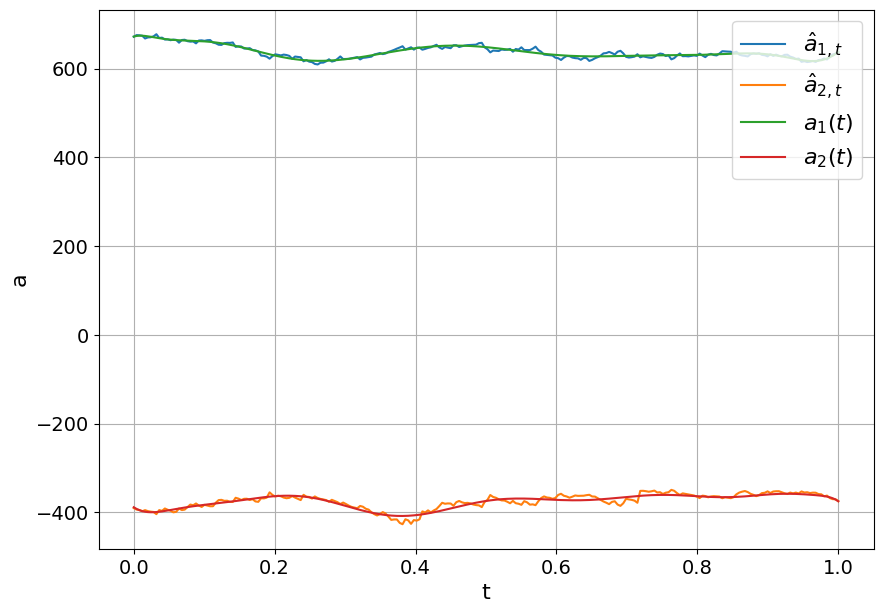

In [949]:
deg = 15

t_data = np.linspace(0, 1, T)
a_data_a1 = a_data[:,1].copy()
a_data_a2 = a_data[:,2].copy()

fit_type = 'right-sided'

# val = np.minimum(np.mean(a_data_a2), 0)
# if a_data_a2[-1] > val:
#     a_data_a2[-1] = val

#r = np.log(np.abs(alpha[0]/alpha[2]**2))
r = 0.0
print(r)

a1_params = bounded_polynom_fit(t_data, a_data_a1, dim = deg, ridge_alpha = r, type = fit_type)
a2_params = bounded_polynom_fit(t_data, a_data_a2, dim = deg, ridge_alpha = r, type = fit_type)

a1t = bounded_polynom(t_data, a_data_a1, a1_params, type = fit_type)
a2t = bounded_polynom(t_data, a_data_a2, a2_params, type = fit_type)

a1t0, a2t0 = a1t, a2t
#a2t = correction(t_data, a2t, alpha)

plt.figure(figsize=(10, 7))

plt.plot(t_data, a_data[:,1], label = r'$\hat{a}_{1,t}$')
plt.plot(t_data, a_data[:,2], label = r'$\hat{a}_{2,t}$')

plt.plot(t_data, a1t, label = r'$a_1(t)$')
plt.plot(t_data, a2t, label = r'$a_2(t)$')


plt.xlabel('t', fontsize=16)
plt.ylabel('a', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)
plt.legend(fontsize=16, loc = 'upper right')

In [352]:
@jit(nopython=True, cache = True)
def mod_abs(x):
    b = 1
    #res = x * (2 / (1 + np.exp(-b * x)) - 1)
    res = x * np.tanh(b * x)
    return res

@jit(nopython=True, cache = True)
def correction(t_data, x_data, alpha):
    #alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    theta, mu, nu = alpha[0], alpha[1], alpha[2]
    sigma2 = nu**2 / (2 * theta) * (1 - np.exp(-2 * theta * t_data)) + 0.0001
    max_res = 1 / (2 * sigma2) - 0.1
    #exp_res = np.exp(-50*(max_res - x_data))
    #return 1 / (1 + exp_res) * x_data
    #max_res = 0.0
    return -(mod_abs(max_res - x_data) - max_res - x_data) / 2

In [870]:
#s = np.random.randint(0, 1000000)
#s = 366495
rng = np.random.RandomState(seed= s)
dwt = rng.normal(0, 1, size = (len(data), latent_process_tr)) * np.sqrt(1/len(data))

log_likelihood = np.zeros(latent_process_tr)
norm_log_data = np.zeros((T, latent_process_tr))

alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
mu = alpha2

#a1t = 1 + t_data #14 * np.sin(8 * np.pi/2 * t_data)
#a2t = 0 *  t_data #-12 * np.cos(4 * np.pi/2 * t_data)**2
#a1t = 5 * t_data #* 0
#a2t = -30 * t_data # * 0

lambda_data = m_sampler_ou(alpha, a1t, a2t, dwt, None)
# dt = 1/T
# for i in range(1, T):
#     a1, a2 = a1t[i], a2t[i]
#     #norm_log_data[i] = log_norm_ou_test(lambda_data[i], i/T, alpha, mu, a1, a2)
#     norm_log_data[i] = log_norm_ou(alpha, a1, a2, 1/T, lambda_data[i - 1])
#     #norm_log_data[i] = log_norm_ou(alpha, a1, a2, i/T, mu)
dt = 1/T
for i in range(T - 1, 0, -1):
    a1, a2 = a1t[i], a2t[i]
    norm_log_data[i] = log_norm_ou(alpha, a1, a2, dt, lambda_data[i - 1])

if init_state is None:
    x0 = mu * np.ones(latent_process_tr)
else:
    x0 = init_state
norm_log_data[0] =  log_norm_ou(alpha, a1t[0], a2t[0], dt, x0)

#norm_log_data[0] = log_norm_ou(alpha, a1t[0], a2t[0], dt, lambda_data[0])

for k in range(0, latent_process_tr):
    copula_log_data = np.log(np.maximum(copula.np_pdf()(data.T, copula.transform(lambda_data[:,k])), 1e-100))
    g = (a1t * (lambda_data[:,k] - 0 * mu)  + a2t * (lambda_data[:,k] - 0 * mu)**2)
    log_likelihood[k] = np.sum(copula_log_data + norm_log_data[:,k] - g)
xc = np.max(log_likelihood)
avg_likelihood = np.sum(np.exp(log_likelihood - xc)) / latent_process_tr
res = np.log(avg_likelihood) + xc
print(-res)
p_jit_mlog_likelihood_ou(alpha, data, dwt, latent_process_tr, False, copula.np_pdf(), copula.transform)


-171.45431008178795


-167.2543123144541

In [748]:
def log_pdf_p(x, t, alpha, x0):
    alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    mu = -alpha1 / alpha2
    theta = -alpha2
    nu = alpha3
    D = nu**2/2
    if t == 0:
        t = t + 0.01
    sigma2 = D / theta * (1 - np.exp(- 2 * theta * t))
    xs = (x0 - mu) * np.exp(-theta * t) + mu
    return  -1/2 * np.log(2 * np.pi * sigma2) - (x - xs)**2 / (2 * sigma2)

In [ ]:
lp = [100, 200, 500, 1000, 5000, 10000]
alpha = np.array([-0.19788412463810046, 0.6706628689464917, -0.7031497915906386])

print(alpha)
for lp_i in lp:
    res_p_i = []
    for k in range(0, 50):
        dwt = np.random.normal(0, 1, size = (T, lp_i)) * np.sqrt(1/T)
        res = p_jit_mlog_likelihood_ou(alpha, pobs_data, dwt, lp_i, False, copula.np_pdf(), copula.transform)
        res_p_i.append(res)
    print(lp_i, np.mean(res_p_i), np.std(res_p_i) )

In [995]:
#lp = [100, 200, 500, 1000, 5000, 10000]
lp = [500]
#alpha = np.array([-0.19788412463810046, 0.6706628689464917, -0.7031497915906386])

print(alpha)
for lp_i in lp:
    res_p_i = []
    for k in range(0, 50):
        dwt = np.random.normal(0, 1, size = (T, lp_i)) * np.sqrt(1/T)
        res = m_jit_mlog_likelihood_ou(alpha, data, dwt, lp_i, 5, False, copula.np_pdf(), copula.transform)
        if np.isnan(res):
            break
        res_p_i.append(res)
    break
print(lp_i, np.mean(res_p_i), np.std(res_p_i) )

[-3.06908433  1.030595   -0.1119058 ]
0.0
0.0
0.0
0.0
0.0
[   38.08071503  -613.96637724  3088.98192156 -4988.7719985
  2301.48716236]
0.0
0.0
0.0
0.0
0.0
[   37.93768401  -622.21358168  3169.33587201 -5179.60023445
  2428.2282231 ]
0.0
0.0
0.0
0.0
0.0
[   37.61828516  -617.27020799  3135.24799846 -5131.44242694
  2417.6468654 ]
0.0
0.0
0.0
0.0
0.0
[   38.21615854  -600.15704078  3017.7895186  -4919.83500705
  2305.14405847]
0.0
0.0
0.0
0.0
0.0
[   37.6509985   -602.27850626  3033.55771685 -4938.39311372
  2308.65851866]
0.0
0.0
0.0
0.0
0.0
[   38.1062844   -611.06281218  3091.75100375 -5053.50926133
  2376.23743978]
0.0
0.0
0.0
0.0
0.0
[   37.36610966  -592.68722167  2991.55373753 -4873.44760601
  2273.04684396]
0.0
0.0
0.0
0.0
0.0
[   37.84943702  -618.71910229  3167.73716647 -5220.49529517
  2480.40312419]
0.0
0.0
0.0
0.0
0.0
[   37.96874567  -619.0888933   3144.11484607 -5125.62266729
  2392.83531892]
0.0
0.0
0.0
0.0
0.0
[   37.49863618  -604.24075294  3068.6429882  -4985.98343722


In [808]:
#dwt = np.random.normal(0, 1, size = (T, latent_process_tr)) * np.sqrt(1/T)
# a1t = np.sin(8 * np.pi/2 * t_data)
# a2t = np.zeros(T)
p = p_sampler_ou(alpha, dwt, init_state)
m = m_sampler_ou(alpha, a1t, a2t, dwt, init_state)

In [584]:
dt = 1/T
a1dt = []
a2dt = []
for i in range(1, T):
    a1dti, a2dti =  (a1t[i] - a1t[i - 1]) / dt, (a2t[i] - a2t[i - 1]) / dt
    a1dt.append(a1dti)
    a2dt.append(a2dti)

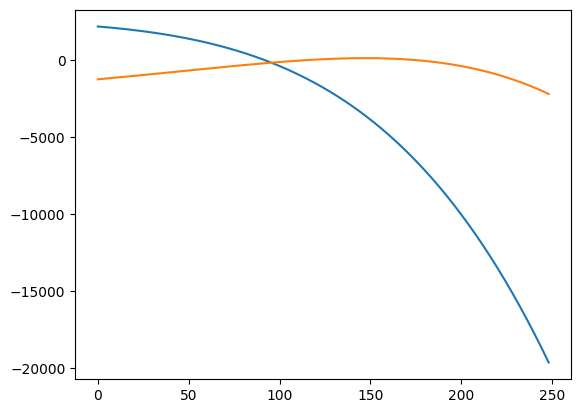

In [585]:
plt.plot(a1dt)
plt.plot(a2dt)

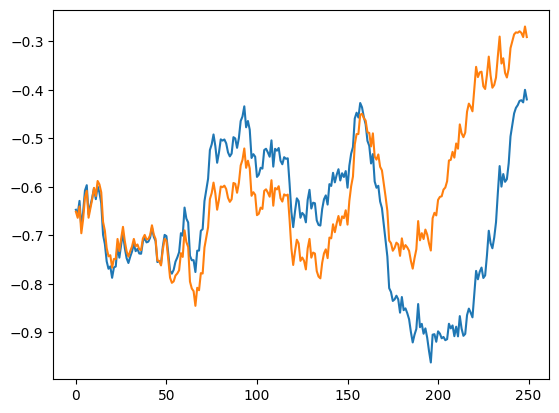

In [823]:
for i in range(0, 1):
    t = np.random.randint(0, latent_process_tr)
    plt.plot(m[:,t], label = f'm {t}')
    plt.plot(p[:,t], label = f'p {t}')